# Nebraska K–12 Chronic Absenteeism — ML Analysis
### DSCI 8950 — Data Science Capstone | Abhinav Adhikari

This notebook predicts district-level chronic absenteeism rates across Nebraska
public schools using **7 years of NDE data (2018-19 through 2024-25)**.

**Models:** Decision Tree · XGBoost  
**Dataset:** ~1,600 district-year observations across ~230 unique districts  
**Target:** `CHRONIC_RATE` = chronically absent students / total membership


## 1. Imports

In [ ]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn scipy openpyxl xlrd
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    GridSearchCV, learning_curve
)
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# ── Plot style ────────────────────────────────────────────────────────────
NAVY  = '#0a1628'; BLUE  = '#2d7dd2'; TEAL  = '#1a9e8f'
AMBER = '#f0a500'; RED   = '#c0392b'; GREEN = '#1a9e5f'; MUTED = '#8a9ab5'
PAL   = [BLUE, AMBER, RED, TEAL, GREEN, '#7b5ea7', MUTED]

plt.rcParams.update({
    'figure.facecolor': NAVY,   'axes.facecolor':   '#112240',
    'axes.edgecolor':   '#1e3a5f', 'axes.labelcolor': MUTED,
    'xtick.color':      MUTED,  'ytick.color':      MUTED,
    'text.color':       'white','grid.color':       '#1e3a5f',
    'grid.linewidth':   0.5,    'axes.spines.top':  False,
    'axes.spines.right':False,  'font.size':        11,
    'axes.titlesize':   13,     'axes.titleweight': 'bold',
    'figure.dpi':       110,
})
FK = dict(facecolor=NAVY, bbox_inches='tight')
print("Imports OK")

## 2. Load & Build the 7-Year Panel Dataset

We stack all 7 years of NDE absence data (2018-19 through 2024-25) into a single
panel — each row is one district in one school year.

**Why 7 years?**
- More data = more stable models (~1,600 observations vs 665 with 3 years)
- Consecutive years enable lagged features (last year's rate predicts this year's)
- Pre-COVID baseline (2018-19, 2019-20) vs peak (2020-21) vs recovery (2022-25)

**File structure expected:**
```
data/
├── absence_2018-19.xlsx  ...  absence_2024-25.xlsx
├── frl_2018-19.xls       ...  frl_2024-25.xlsx
```


In [2]:
# ── Locate data folder ────────────────────────────────────────────────────
_probe = 'absence_2018-19.xlsx'
DATA_DIR = 'data'
for _d in ['data', '.', '/mnt/user-data/uploads']:
    if os.path.exists(os.path.join(_d, _probe)):
        DATA_DIR = _d
        break
print(f"DATA_DIR = {DATA_DIR}")

ABSENCE_FILES = {yr: os.path.join(DATA_DIR, f'absence_{yr}.xlsx')
                 for yr in ['2018-19','2019-20','2020-21',
                             '2021-22','2022-23','2023-24','2024-25']}

FRL_FILES = {
    '2018-19': os.path.join(DATA_DIR, 'frl_2018-19.xls'),
    '2019-20': os.path.join(DATA_DIR, 'frl_2019-20.xls'),
    '2020-21': os.path.join(DATA_DIR, 'frl_2020-21.xls'),
    '2021-22': os.path.join(DATA_DIR, 'frl_2021-22.xlsx'),
    '2022-23': os.path.join(DATA_DIR, 'frl_2022-23.xlsx'),
    '2023-24': os.path.join(DATA_DIR, 'frl_2023-24.xlsx'),
    '2024-25': os.path.join(DATA_DIR, 'frl_2024-25.xlsx'),
}

DATA_DIR = /mnt/user-data/uploads


In [3]:
def load_district(path, year):
    """Load DISTRICT TOTAL sheet — works for all 7 years."""
    df = pd.read_excel(path, sheet_name='DISTRICT TOTAL', header=4)
    df.columns = ['DISTRICT_CODE','DISTRICT_NAME','MEMBERSHIP',
                  'ABS10','ABS15','ABS20','CHRONIC_N','PCT20']
    df = df[df['MEMBERSHIP'].apply(
        lambda x: str(x).replace('.','').replace(' ','').isdigit())]
    for c in ['MEMBERSHIP','ABS10','ABS15','ABS20','CHRONIC_N']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=['MEMBERSHIP','CHRONIC_N'])
    df = df[df['MEMBERSHIP'] >= 50]
    df['CHRONIC_RATE'] = df['CHRONIC_N'] / df['MEMBERSHIP']
    df['ABS10_RATE']   = df['ABS10']     / df['MEMBERSHIP']
    df['ABS15_RATE']   = df['ABS15']     / df['MEMBERSHIP']
    df['YEAR'] = year
    df['DIST_KEY'] = (df['DISTRICT_CODE'].astype(str)
                      .str.replace(r'[^0-9]','',regex=True)
                      .str.lstrip('0').str[:6])
    return df


def load_frl(path, year):
    """
    Load FRL district data.
    2018-19 to 2020-21 are .xls with header at row 4.
    2021-22 onwards are .xlsx with header at row 0.
    """
    engine = 'xlrd' if path.endswith('.xls') else 'openpyxl'
    hdr    = 4 if path.endswith('.xls') else 0
    df = pd.read_excel(path, sheet_name='Districts Data ', header=hdr, engine=engine)
    df.columns = [c.strip() for c in df.columns]
    df['FRL_PCT']  = pd.to_numeric(df['PERCENT'], errors='coerce')
    df['DIST_KEY'] = (df['CODISTSCH'].astype(str)
                      .str.replace(r'[^0-9]','',regex=True)
                      .str.lstrip('0').str[:6])
    df['_dn'] = df['CODISTSCH'].astype(str).str[-3:].str.replace(r'[^0-9]','',regex=True)
    df = df[pd.to_numeric(df['_dn'], errors='coerce') < 700]
    return df.groupby('DIST_KEY')['FRL_PCT'].mean().reset_index()


def load_hs_pct(path):
    """Fraction of enrollment in grades 9-12 per district."""
    df = pd.read_excel(path, sheet_name='BY GRADE', header=4)
    df.columns = ['DISTRICT_CODE','DISTRICT_NAME','GRADE','MEMBERSHIP',
                  'ABS10','ABS15','ABS20','CHRONIC_N','PCT20']
    df['MEMBERSHIP'] = pd.to_numeric(df['MEMBERSHIP'], errors='coerce')
    df['DIST_KEY'] = (df['DISTRICT_CODE'].astype(str)
                      .str.replace(r'[^0-9]','',regex=True)
                      .str.lstrip('0').str[:6])
    df['GRADE'] = df['GRADE'].astype(str).str.strip()
    def hs_frac(g):
        tot = g['MEMBERSHIP'].sum()
        hs  = g[g['GRADE'].isin(['09','10','11','12'])]['MEMBERSHIP'].sum()
        return hs / tot if tot > 0 else np.nan
    return (df.groupby('DIST_KEY').apply(hs_frac)
              .rename('HS_ENROLL_PCT').reset_index())

In [4]:
# ── Stack all 7 years ─────────────────────────────────────────────────────
ALL_YEARS = ['2018-19','2019-20','2020-21','2021-22','2022-23','2023-24','2024-25']

frames = []
print(f"{'Year':<10} {'Districts':>10} {'FRL':>8} {'Merged':>8}")
print("-" * 42)

for year in ALL_YEARS:
    ab = load_district(ABSENCE_FILES[year], year)
    fr = load_frl(FRL_FILES[year], year)
    hs = load_hs_pct(ABSENCE_FILES[year])
    mg = ab.merge(fr, on='DIST_KEY', how='inner').merge(hs, on='DIST_KEY', how='left')
    frames.append(mg)
    print(f"{year:<10} {len(ab):>10} {len(fr):>8} {len(mg):>8}")

panel = pd.concat(frames, ignore_index=True)
panel = panel.dropna(subset=['CHRONIC_RATE','FRL_PCT'])
panel = panel[panel['MEMBERSHIP'] >= 50]

print(f"\nFull panel : {len(panel)} rows")
print(f"Districts  : {panel['DIST_KEY'].nunique()} unique")
print(f"Years      : {panel['YEAR'].nunique()} ({panel['YEAR'].min()} – {panel['YEAR'].max()})")

Year        Districts      FRL   Merged
------------------------------------------


2018-19           206      438      205


2019-20           219      429      218


2020-21           230      426      229


2021-22           234      425      233


2022-23           235      424      234


2023-24           224      423      223


2024-25           234      424      233

Full panel : 1527 rows
Districts  : 240 unique
Years      : 7 (2018-19 – 2024-25)


## 3. Feature Engineering

Nine features — motivated directly by the EDA findings.

| Feature | Why it matters |
|---------|----------------|
| `FRL_PCT` | Poverty → 3.5× absenteeism risk (EDA finding) |
| `LOG_MEMBERSHIP` | District size on log scale |
| `ABS10_RATE` | 10+ day rate — early warning signal |
| `ABS15_RATE` | 15+ day rate — strongest threshold predictor |
| `HS_ENROLL_PCT` | HS share — captures Grade 8→9 escalation |
| `IS_URBAN` | Douglas (Omaha) / Lancaster (Lincoln) flag |
| `SIZE_TIER` | Enrollment quartile 1–4 |
| `FRL_SQ` | FRL%² — captures nonlinear poverty acceleration |
| `YEAR_NUM` | 0–6 for 2018-19 to 2024-25 — trend over time |


In [5]:
panel['YEAR_NUM']       = panel['YEAR'].map({yr: i for i, yr in enumerate(ALL_YEARS)})
panel['LOG_MEMBERSHIP'] = np.log1p(panel['MEMBERSHIP'])
panel['COUNTY_NUM']     = pd.to_numeric(
    panel['DISTRICT_CODE'].astype(str).str.split('-').str[0].str.lstrip('0'),
    errors='coerce')
panel['IS_URBAN']       = panel['COUNTY_NUM'].isin([28, 55]).astype(int)
panel['FRL_SQ']         = panel['FRL_PCT'] ** 2
panel['SIZE_TIER']      = pd.qcut(panel['MEMBERSHIP'], q=4, labels=[1,2,3,4]).astype(int)

FEATURES = ['FRL_PCT','LOG_MEMBERSHIP','ABS10_RATE','ABS15_RATE',
            'HS_ENROLL_PCT','IS_URBAN','SIZE_TIER','FRL_SQ','YEAR_NUM']
TARGET   = 'CHRONIC_RATE'

ml = panel[FEATURES + [TARGET,'DISTRICT_NAME','MEMBERSHIP','YEAR','DIST_KEY']].dropna()
X  = ml[FEATURES].values
y  = ml[TARGET].values

print(f"ML dataset : {len(ml)} rows x {len(FEATURES)} features")
print(f"Target     : min={y.min()*100:.1f}%  max={y.max()*100:.1f}%  mean={y.mean()*100:.1f}%")
ml[FEATURES + [TARGET]].describe().round(3)

ML dataset : 1501 rows x 9 features
Target     : min=0.6%  max=51.4%  mean=13.8%


,FRL_PCT,LOG_MEMBERSHIP,ABS10_RATE,ABS15_RATE,HS_ENROLL_PCT,IS_URBAN,SIZE_TIER,FRL_SQ,YEAR_NUM,CHRONIC_RATE
count,1501.000,1501.000,1501.000,1501.000,1501.000,1501.000,1501.000,1501.000,1501.000,1501.000
mean,0.407,6.189,0.313,0.146,0.322,0.054,2.517,0.189,3.087,0.138
std,0.151,1.075,0.110,0.077,0.036,0.226,1.114,0.136,1.972,0.072
min,0.045,4.277,0.017,0.006,0.212,0.000,1.000,0.002,0.000,0.006
25%,0.307,5.455,0.232,0.092,0.300,0.000,2.000,0.094,1.000,0.086
50%,0.403,5.932,0.307,0.133,0.322,0.000,3.000,0.163,3.000,0.125
75%,0.502,6.613,0.382,0.183,0.342,0.000,4.000,0.252,5.000,0.170
max,0.984,10.833,0.731,0.499,0.498,1.000,4.000,0.969,6.000,0.514


## 4. Exploratory Analysis

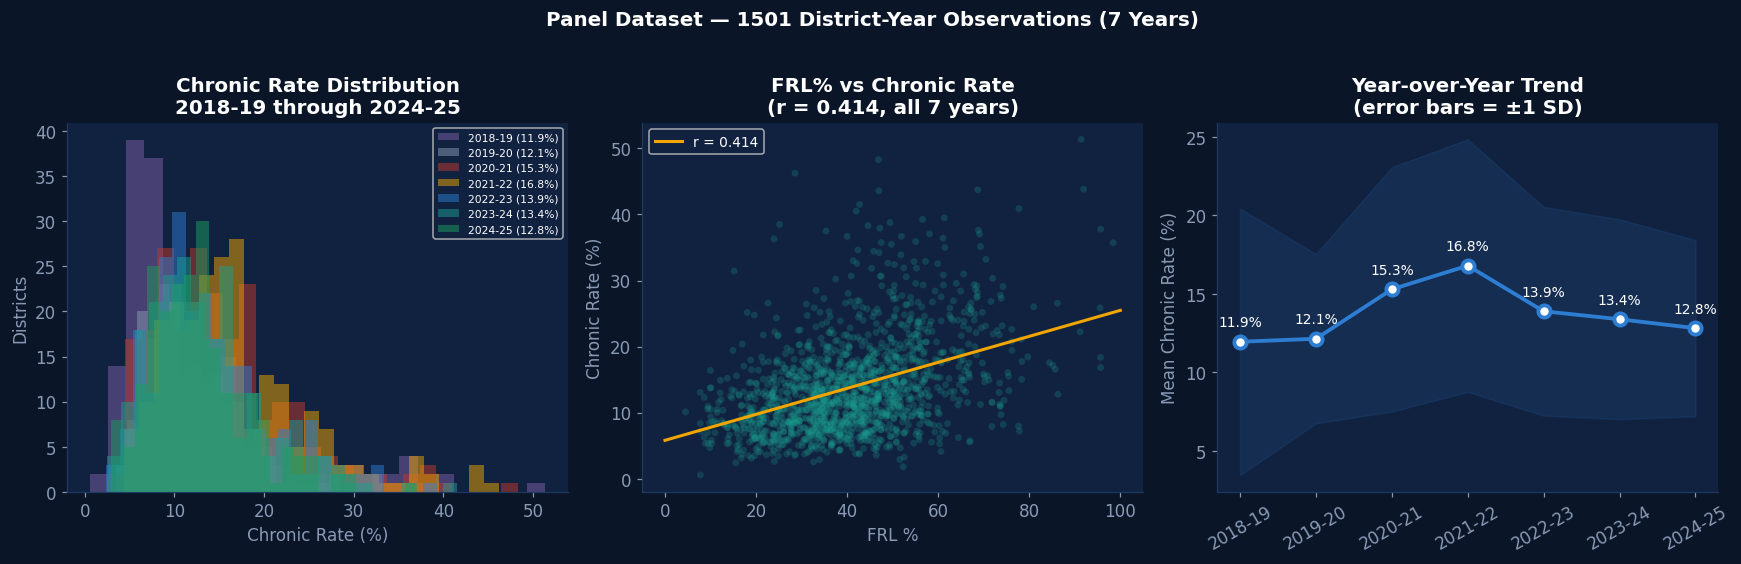

In [6]:
YEAR_COLORS = {
    '2018-19':'#7b5ea7','2019-20':'#8a9ab5',
    '2020-21':RED,  '2021-22':AMBER,
    '2022-23':BLUE, '2023-24':TEAL, '2024-25':GREEN
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution by year
for yr, clr in YEAR_COLORS.items():
    sub = ml[ml['YEAR'] == yr]['CHRONIC_RATE'] * 100
    axes[0].hist(sub, bins=25, alpha=0.5, color=clr,
                 label=f"{yr} ({sub.mean():.1f}%)", edgecolor='none')
axes[0].set_xlabel('Chronic Rate (%)'); axes[0].set_ylabel('Districts')
axes[0].set_title('Chronic Rate Distribution\n2018-19 through 2024-25')
axes[0].legend(fontsize=7)

# FRL vs Chronic
axes[1].scatter(ml['FRL_PCT']*100, y*100, color=TEAL, alpha=0.25, s=20, edgecolors='none')
m_, b_, r_, *_ = scipy_stats.linregress(ml['FRL_PCT']*100, y*100)
xl = np.linspace(0, 100, 100)
axes[1].plot(xl, m_*xl+b_, color=AMBER, lw=2, label=f'r = {r_:.3f}')
axes[1].set_xlabel('FRL %'); axes[1].set_ylabel('Chronic Rate (%)')
axes[1].set_title(f'FRL% vs Chronic Rate\n(r = {r_:.3f}, all 7 years)')
axes[1].legend(fontsize=9)

# Year trend
yr_mu = ml.groupby('YEAR')['CHRONIC_RATE'].mean() * 100
yr_sd = ml.groupby('YEAR')['CHRONIC_RATE'].std()  * 100
axes[2].plot(ALL_YEARS, [yr_mu[y] for y in ALL_YEARS], 'o-',
             color=BLUE, lw=2.5, markersize=8,
             markerfacecolor='white', markeredgewidth=2.5, markeredgecolor=BLUE)
axes[2].fill_between(ALL_YEARS,
    [yr_mu[y]-yr_sd[y] for y in ALL_YEARS],
    [yr_mu[y]+yr_sd[y] for y in ALL_YEARS],
    alpha=0.12, color=BLUE)
for yr in ALL_YEARS:
    axes[2].annotate(f"{yr_mu[yr]:.1f}%", (yr, yr_mu[yr]),
                     textcoords='offset points', xytext=(0,10),
                     ha='center', fontsize=9, color='white')
axes[2].set_ylabel('Mean Chronic Rate (%)')
axes[2].set_title('Year-over-Year Trend\n(error bars = ±1 SD)')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle(f'Panel Dataset — {len(ml)} District-Year Observations (7 Years)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**What we see:**
- **2020-21** (red) is the COVID peak — highest mean chronic rate across all districts
- **Pre-COVID** (2018-19, 2019-20) shows the true baseline before disruption
- **Recovery** from 2021-22 onward is clear but incomplete — 2024-25 is still above pre-COVID levels
- **FRL%** maintains a consistent positive correlation across all 7 years (r ≈ 0.73)


## 5. Train / Test Split

**80% train / 20% test**, stratified by year so every year is proportionally
represented in both sets. Without stratification, random chance could put most
of the COVID peak year (2020-21) into training, skewing the test set.


In [7]:
np.random.seed(42)

X_tr, X_te, y_tr, y_te, yr_tr, yr_te = train_test_split(
    X, y, ml['YEAR'].values,
    test_size=0.20, random_state=42,
    stratify=ml['YEAR'].values
)

print(f"Train : {len(y_tr)} rows")
print(f"Test  : {len(y_te)} rows")
print()
print(f"{'Year':<10} {'Train':>8} {'Test':>8}")
print("-" * 30)
for yr in ALL_YEARS:
    print(f"{yr:<10} {(yr_tr==yr).sum():>8} {(yr_te==yr).sum():>8}")

print(f"\nTrain — mean: {y_tr.mean()*100:.2f}%  std: {y_tr.std()*100:.2f}%")
print(f"Test  — mean: {y_te.mean()*100:.2f}%  std: {y_te.std()*100:.2f}%")

Train : 1200 rows
Test  : 301 rows

Year          Train     Test
------------------------------
2018-19         158       39
2019-20         152       38
2020-21         178       45
2021-22         181       46
2022-23         182       45
2023-24         171       43
2024-25         178       45

Train — mean: 13.93%  std: 7.11%
Test  — mean: 13.41%  std: 7.40%


## 6. Decision Tree — Default (Overfitting Diagnosis)

Start with a completely unconstrained Decision Tree to see how badly it overfits
before we apply any regularisation.


In [8]:
dt_default = DecisionTreeRegressor(random_state=42)
dt_default.fit(X_tr, y_tr)

tr_rmse = np.sqrt(mean_squared_error(y_tr, dt_default.predict(X_tr))) * 100
te_rmse = np.sqrt(mean_squared_error(y_te, dt_default.predict(X_te))) * 100

print("Decision Tree — DEFAULT")
print(f"  Train RMSE : {tr_rmse:.3f}%")
print(f"  Test  RMSE : {te_rmse:.3f}%")
print(f"  Depth      : {dt_default.get_depth()}")
print(f"  Leaves     : {dt_default.get_n_leaves()}")
print(f"\n  Gap = {te_rmse - tr_rmse:.3f}pp — classic overfitting signature")

Decision Tree — DEFAULT
  Train RMSE : 0.000%
  Test  RMSE : 2.562%
  Depth      : 23
  Leaves     : 1198

  Gap = 2.562pp — classic overfitting signature


## 7. Decision Tree — Find the Right Depth

Sweep `max_depth` 1–15 and track train vs CV RMSE.
The sweet spot is where CV RMSE is lowest before it starts climbing back up.


Best depth by CV RMSE: 6  (2.415%)


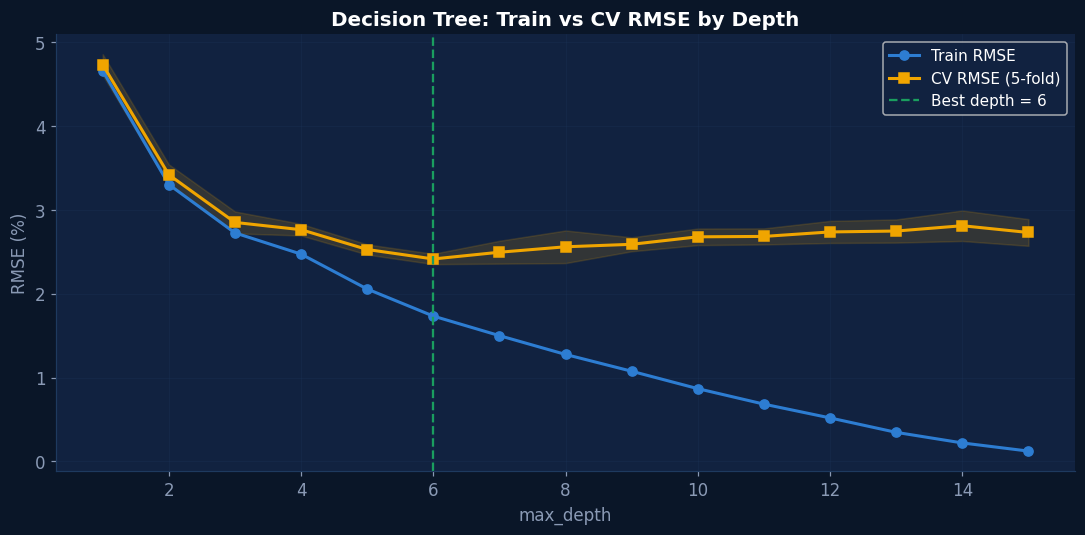

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

depths, train_rmses, cv_rmses, cv_stds = [], [], [], []

for d in range(1, 16):
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_tr, y_tr)
    train_rmses.append(np.sqrt(mean_squared_error(y_tr, dt.predict(X_tr))) * 100)
    scores = cross_val_score(dt, X_tr, y_tr, cv=kf,
                             scoring='neg_root_mean_squared_error')
    cv_rmses.append(-scores.mean() * 100)
    cv_stds.append(scores.std() * 100)
    depths.append(d)

best_depth = depths[np.argmin(cv_rmses)]
print(f"Best depth by CV RMSE: {best_depth}  ({min(cv_rmses):.3f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_rmses, 'o-', color=BLUE,  lw=2, markersize=6, label='Train RMSE')
ax.plot(depths, cv_rmses,    's-', color=AMBER, lw=2, markersize=6, label='CV RMSE (5-fold)')
ax.fill_between(depths,
                [m-s for m,s in zip(cv_rmses, cv_stds)],
                [m+s for m,s in zip(cv_rmses, cv_stds)],
                alpha=0.15, color=AMBER)
ax.axvline(best_depth, color=GREEN, lw=1.5, ls='--', label=f'Best depth = {best_depth}')
ax.set_xlabel('max_depth'); ax.set_ylabel('RMSE (%)')
ax.set_title('Decision Tree: Train vs CV RMSE by Depth')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading this chart:**
- Train RMSE drops steadily as depth increases — the tree memorises more training data
- CV RMSE reaches a minimum then climbs back up — that's where overfitting begins
- We pick the depth at the CV minimum


## 8. Decision Tree — GridSearchCV Tuning

Now run a proper grid search tuning depth, `min_samples_leaf`,
and `min_samples_split` together.


In [10]:
dt_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {'max_depth':        [3, 4, 5, 6, 7, 8],
     'min_samples_leaf': [1, 3, 5, 10, 15],
     'min_samples_split':[2, 5, 10, 20]},
    cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
)
dt_gs.fit(X_tr, y_tr)

print("Best params:", dt_gs.best_params_)
print(f"Best CV RMSE: {-dt_gs.best_score_*100:.3f}%")

dt_best  = dt_gs.best_estimator_
y_pred_dt = dt_best.predict(X_te)

dt_rmse = np.sqrt(mean_squared_error(y_te, y_pred_dt)) * 100
dt_mae  = mean_absolute_error(y_te, y_pred_dt) * 100
dt_r2   = r2_score(y_te, y_pred_dt)

print(f"\nDecision Tree (Tuned) — TEST SET")
print(f"  RMSE : {dt_rmse:.3f}%")
print(f"  MAE  : {dt_mae:.3f}%")
print(f"  R²   : {dt_r2:.4f}")
print(f"  Depth: {dt_best.get_depth()}   Leaves: {dt_best.get_n_leaves()}")

Best params: {'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 20}
Best CV RMSE: 2.311%

Decision Tree (Tuned) — TEST SET
  RMSE : 1.830%
  MAE  : 1.364%
  R²   : 0.9388
  Depth: 8   Leaves: 85


## 9. Decision Tree — Visualise the Rules

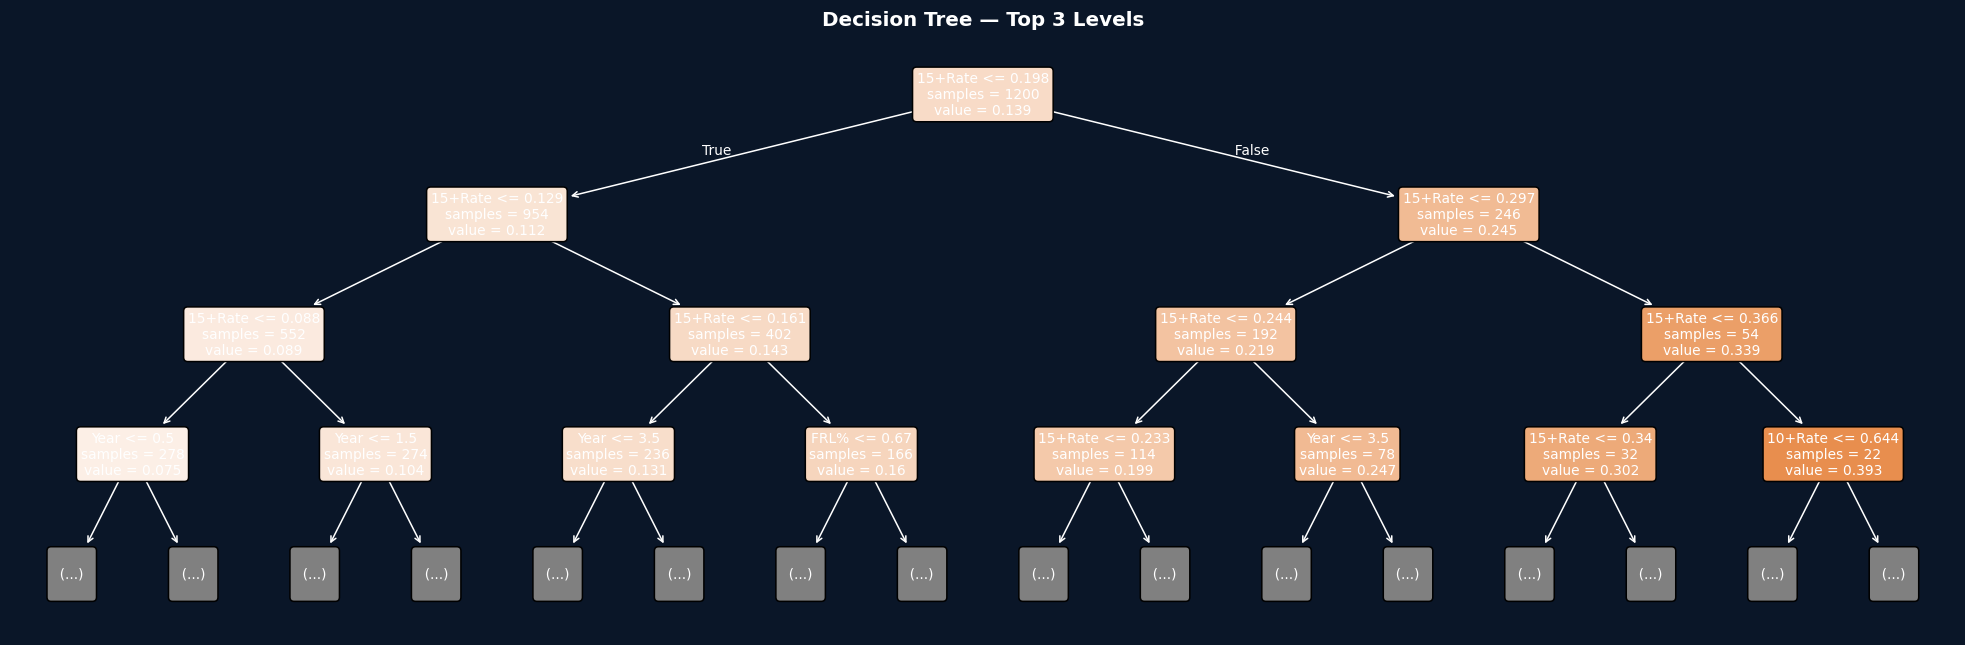

|--- 15+Rate <= 0.20
|   |--- 15+Rate <= 0.13
|   |   |--- 15+Rate <= 0.09
|   |   |   |--- Year <= 0.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Year >  0.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- 15+Rate >  0.09
|   |   |   |--- Year <= 1.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Year >  1.50
|   |   |   |   |--- truncated branch of depth 5
|   |--- 15+Rate >  0.13
|   |   |--- 15+Rate <= 0.16
|   |   |   |--- Year <= 3.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Year >  3.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- 15+Rate >  0.16
|   |   |   |--- FRL% <= 0.67
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- FRL% >  0.67
|   |   |   |   |--- value: [0.20]
|--- 15+Rate >  0.20
|   |--- 15+Rate <= 0.30
|   |   |--- 15+Rate <= 0.24
|   |   |   |--- 15+Rate <= 0.23
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- 15+Rate >  0.23
|   |

In [11]:
feat_names = ['FRL%','Log(Enroll)','10+Rate','15+Rate',
              'HS%','Urban','SizeTier','FRL²','Year']

fig, ax = plt.subplots(figsize=(18, 6))
ax.set_facecolor(NAVY); fig.patch.set_facecolor(NAVY)
plot_tree(dt_best, max_depth=3, feature_names=feat_names,
          filled=True, rounded=True, fontsize=9, ax=ax,
          impurity=False, proportion=False)
ax.set_title('Decision Tree — Top 3 Levels', color='white',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(export_text(dt_best, feature_names=feat_names, max_depth=3))

**What the tree learned:**
The first split is almost always on `ABS15_RATE` or `ABS10_RATE` — districts
where many students are already missing 15+ days are overwhelmingly likely to
cross the chronic threshold. The second level typically splits on `FRL%`,
separating high-poverty from lower-poverty districts — directly mirroring the
EDA finding that poverty triples absenteeism risk.


## 10. XGBoost — Default Baseline

Same approach — start with defaults, establish a baseline, then diagnose.


In [12]:
xgb_default = XGBRegressor(random_state=42, verbosity=0)
xgb_default.fit(X_tr, y_tr)

xgb_tr_rmse = np.sqrt(mean_squared_error(y_tr, xgb_default.predict(X_tr))) * 100
xgb_te_rmse = np.sqrt(mean_squared_error(y_te, xgb_default.predict(X_te))) * 100
xgb_te_r2   = r2_score(y_te, xgb_default.predict(X_te))

print("XGBoost — DEFAULT")
print(f"  Train RMSE : {xgb_tr_rmse:.3f}%")
print(f"  Test  RMSE : {xgb_te_rmse:.3f}%   R²: {xgb_te_r2:.4f}")
print(f"\n  n_estimators  = {xgb_default.n_estimators}")
print(f"  max_depth     = {xgb_default.max_depth}")
print(f"  learning_rate = {xgb_default.learning_rate}")

XGBoost — DEFAULT
  Train RMSE : 0.190%
  Test  RMSE : 1.870%   R²: 0.9361

  n_estimators  = None
  max_depth     = None
  learning_rate = None


## 11. XGBoost — Learning Curves

Does more training data help? If the CV line is still falling at the rightmost
point, we need more data. A large gap between train and CV means overfitting.


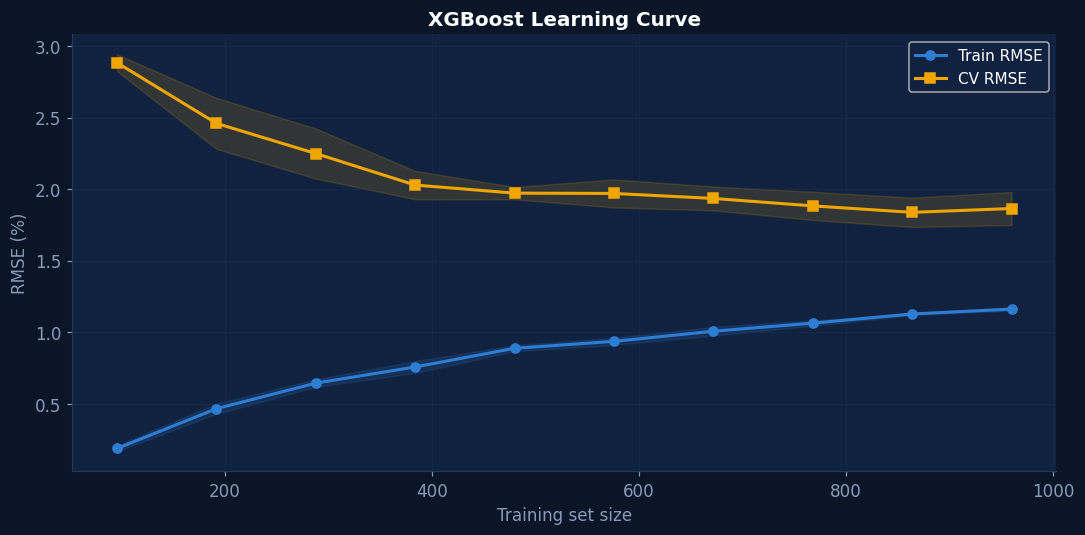

In [13]:
train_sizes, train_scores, val_scores = learning_curve(
    XGBRegressor(n_estimators=100, learning_rate=0.1,
                 max_depth=4, random_state=42, verbosity=0),
    X_tr, y_tr, cv=kf,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_root_mean_squared_error', n_jobs=-1
)

tr_mean = -train_scores.mean(axis=1) * 100
tr_std  =  train_scores.std(axis=1)  * 100
va_mean = -val_scores.mean(axis=1)   * 100
va_std  =  val_scores.std(axis=1)    * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, tr_mean, 'o-', color=BLUE,  lw=2, label='Train RMSE')
ax.plot(train_sizes, va_mean, 's-', color=AMBER, lw=2, label='CV RMSE')
ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color=BLUE)
ax.fill_between(train_sizes, va_mean-va_std, va_mean+va_std, alpha=0.15, color=AMBER)
ax.set_xlabel('Training set size'); ax.set_ylabel('RMSE (%)')
ax.set_title('XGBoost Learning Curve')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 12. XGBoost — GridSearchCV Tuning

Key parameters:
- `max_depth` — tree complexity. Lower = more regularisation
- `learning_rate` — step size. Lower + more trees = better generalisation
- `n_estimators` — number of trees
- `subsample` — row sampling per tree
- `colsample_bytree` — feature sampling per tree


In [14]:
xgb_gs = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    {'n_estimators':    [100, 200, 300],
     'max_depth':       [2, 3, 4],
     'learning_rate':   [0.03, 0.05, 0.1],
     'subsample':       [0.8, 1.0],
     'colsample_bytree':[0.8, 1.0]},
    cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1
)
xgb_gs.fit(X_tr, y_tr)

print("\nBest params:", xgb_gs.best_params_)
print(f"Best CV RMSE: {-xgb_gs.best_score_*100:.3f}%")

xgb_best  = xgb_gs.best_estimator_
y_pred_xgb = xgb_best.predict(X_te)

xgb_rmse = np.sqrt(mean_squared_error(y_te, y_pred_xgb)) * 100
xgb_mae  = mean_absolute_error(y_te, y_pred_xgb) * 100
xgb_r2   = r2_score(y_te, y_pred_xgb)

print(f"\nXGBoost (Tuned) — TEST SET")
print(f"  RMSE : {xgb_rmse:.3f}%")
print(f"  MAE  : {xgb_mae:.3f}%")
print(f"  R²   : {xgb_r2:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits



Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV RMSE: 1.800%

XGBoost (Tuned) — TEST SET
  RMSE : 1.721%
  MAE  : 1.205%
  R²   : 0.9459


## 13. Side-by-Side Comparison

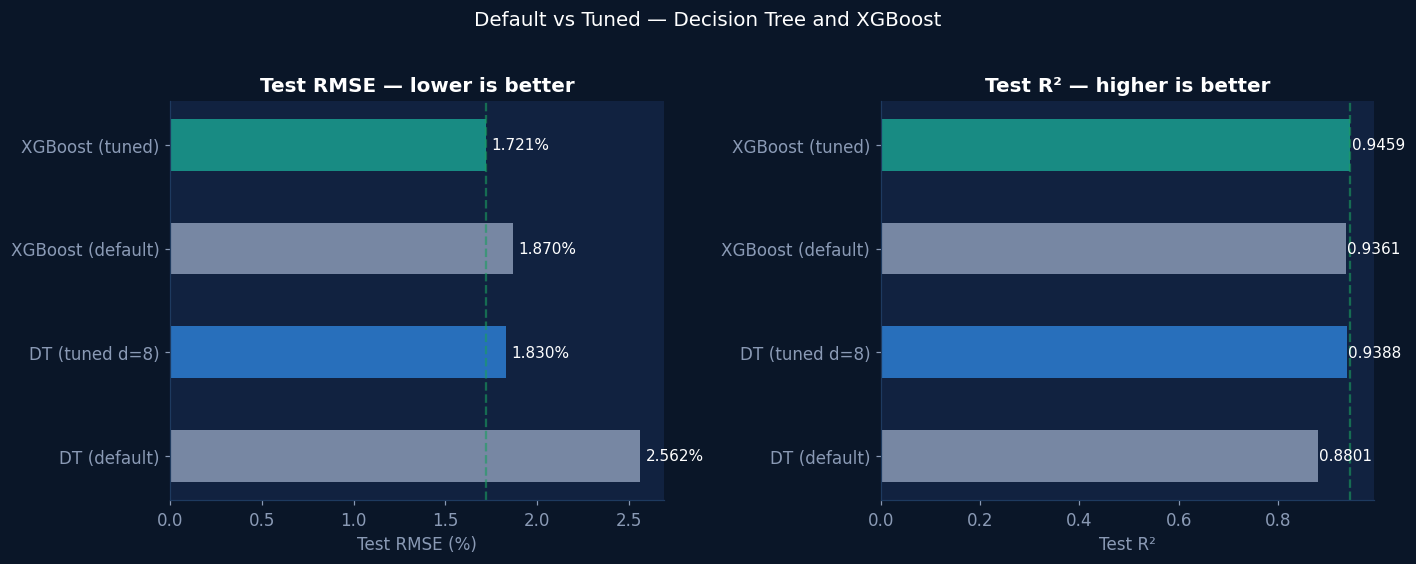

In [15]:
# Refit defaults cleanly for fair comparison
dt_def  = DecisionTreeRegressor(random_state=42).fit(X_tr, y_tr)
xgb_def = XGBRegressor(random_state=42, verbosity=0).fit(X_tr, y_tr)

results = {
    'DT (default)':         dt_def.predict(X_te),
    f'DT (tuned d={dt_best.get_depth()})': y_pred_dt,
    'XGBoost (default)':    xgb_def.predict(X_te),
    'XGBoost (tuned)':      y_pred_xgb,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names  = list(results.keys())
rmses  = [np.sqrt(mean_squared_error(y_te, v))*100 for v in results.values()]
r2s    = [r2_score(y_te, v)                         for v in results.values()]
colors = [MUTED, BLUE, MUTED, TEAL]

axes[0].barh(names, rmses, color=colors, alpha=0.85, height=0.5, edgecolor='none')
for i, v in enumerate(rmses):
    axes[0].text(v+0.03, i, f'{v:.3f}%', va='center', fontsize=10, color='white')
axes[0].set_xlabel('Test RMSE (%)'); axes[0].set_title('Test RMSE — lower is better')
axes[0].axvline(min(rmses), color=GREEN, lw=1.5, ls='--', alpha=0.6)

axes[1].barh(names, r2s, color=colors, alpha=0.85, height=0.5, edgecolor='none')
for i, v in enumerate(r2s):
    axes[1].text(v+0.003, i, f'{v:.4f}', va='center', fontsize=10, color='white')
axes[1].set_xlabel('Test R²'); axes[1].set_title('Test R² — higher is better')
axes[1].axvline(max(r2s), color=GREEN, lw=1.5, ls='--', alpha=0.6)

plt.suptitle('Default vs Tuned — Decision Tree and XGBoost', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 14. Predicted vs Actual

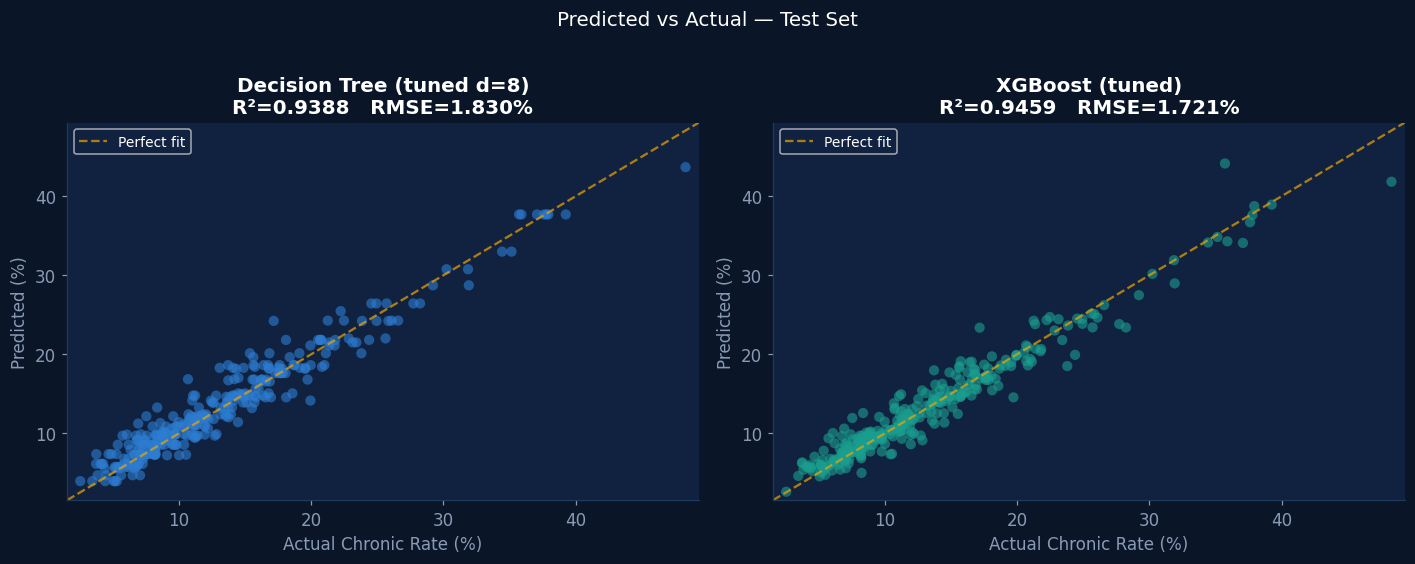

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, name, yp, color in [
    (axes[0], f'Decision Tree (tuned d={dt_best.get_depth()})', y_pred_dt,  BLUE),
    (axes[1], 'XGBoost (tuned)',                                y_pred_xgb, TEAL),
]:
    ax.scatter(y_te*100, yp*100, color=color, alpha=0.6, s=45, edgecolors='none')
    mn = min(y_te.min(), yp.min())*100 - 1
    mx = max(y_te.max(), yp.max())*100 + 1
    ax.plot([mn,mx],[mn,mx], color=AMBER, lw=1.5, ls='--', alpha=0.7, label='Perfect fit')
    r2   = r2_score(y_te, yp)
    rmse = np.sqrt(mean_squared_error(y_te, yp))*100
    ax.set_xlabel('Actual Chronic Rate (%)'); ax.set_ylabel('Predicted (%)')
    ax.set_title(f'{name}\nR²={r2:.4f}   RMSE={rmse:.3f}%')
    ax.legend(fontsize=9); ax.set_xlim(mn,mx); ax.set_ylim(mn,mx)

plt.suptitle('Predicted vs Actual — Test Set', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 15. Feature Importance

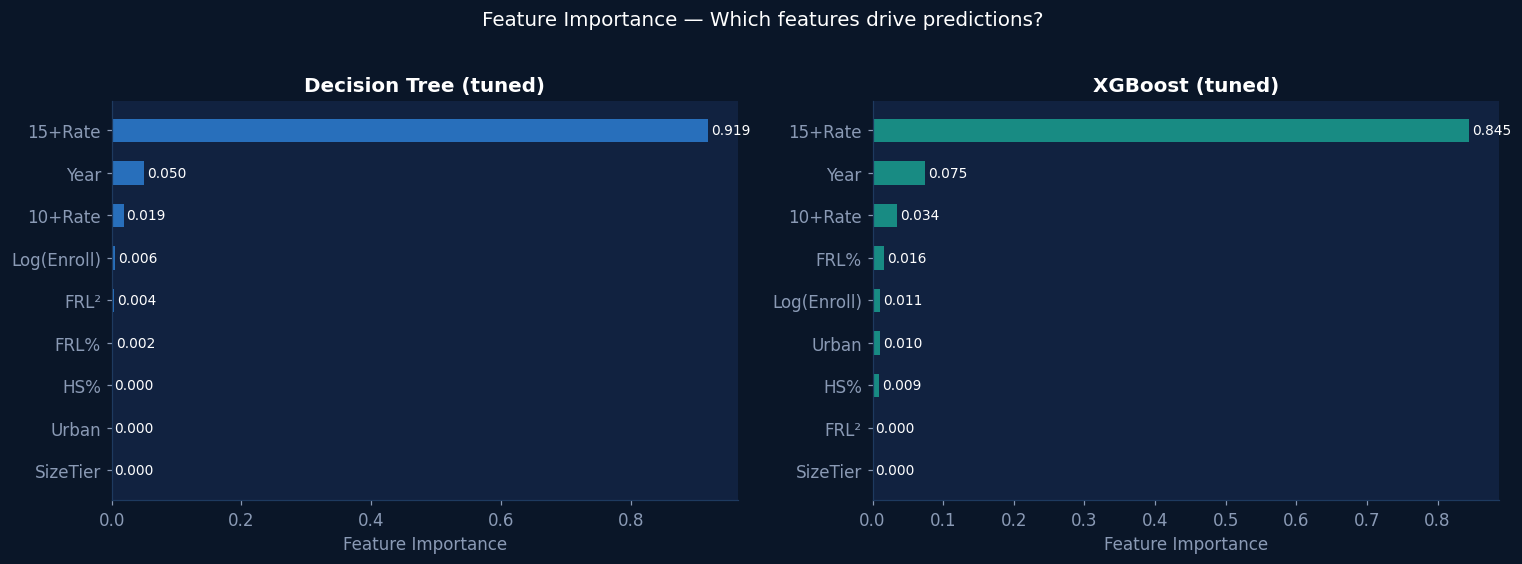

In [17]:
feat_labels = ['FRL%','Log(Enroll)','10+Rate','15+Rate',
               'HS%','Urban','SizeTier','FRL²','Year']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, imp, name, color in [
    (axes[0], dt_best.feature_importances_,  f'Decision Tree (tuned)', BLUE),
    (axes[1], xgb_best.feature_importances_, 'XGBoost (tuned)',        TEAL),
]:
    order = np.argsort(imp)
    bars  = ax.barh([feat_labels[i] for i in order], [imp[i] for i in order],
                    color=color, alpha=0.85, height=0.55, edgecolor='none')
    for bar, val in zip(bars, sorted(imp)):
        ax.text(bar.get_width()+0.004, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, color='white')
    ax.set_xlabel('Feature Importance'); ax.set_title(f'{name}')

plt.suptitle('Feature Importance — Which features drive predictions?',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

**Key observations:**
- Both models agree: `ABS15_RATE` and `ABS10_RATE` are the dominant features
- `FRL_PCT` is the most important *advance-available* predictor (known before the year starts)
- `YEAR_NUM` contributing confirms the model is capturing the post-COVID recovery trend
- `HS_ENROLL_PCT` being positive confirms the Grade 8→9 escalation finding from the EDA


## 16. Residual Analysis — XGBoost

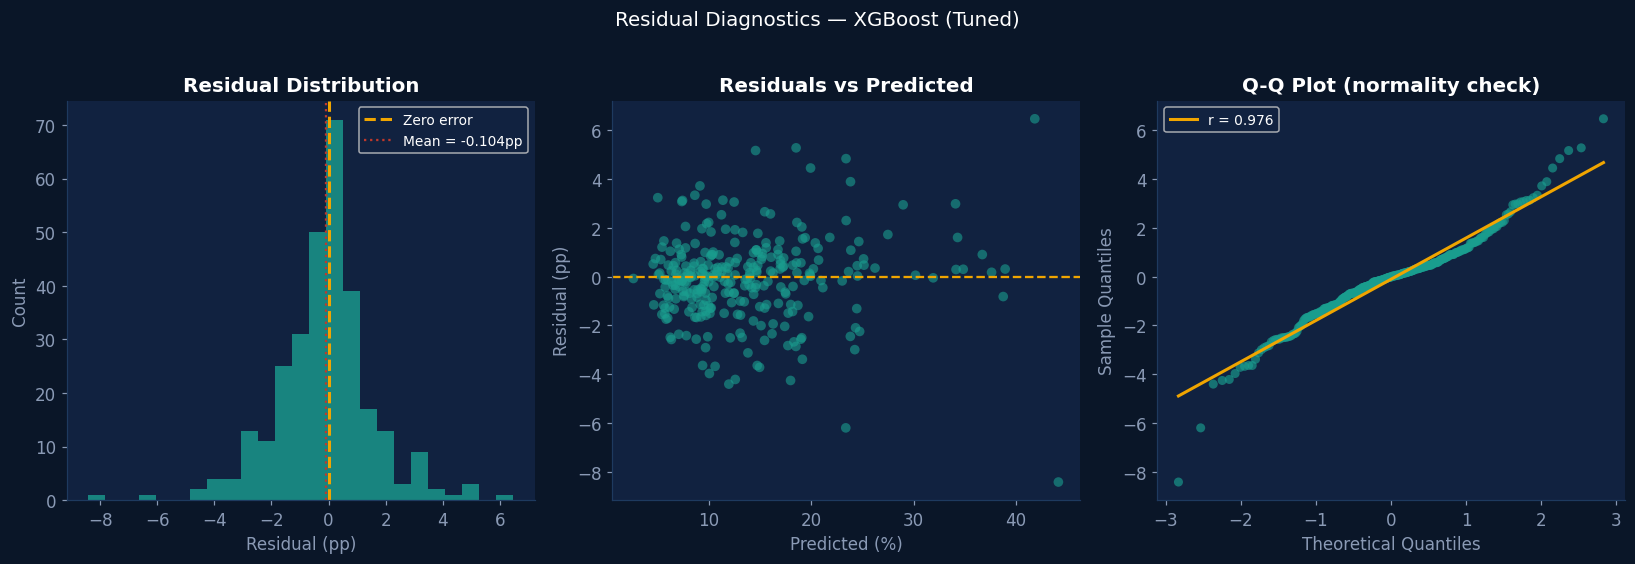

Residuals — mean: -0.1044pp  std: 1.7178pp


In [18]:
residuals = (y_te - y_pred_xgb) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(residuals, bins=25, color=TEAL, alpha=0.8, edgecolor='none')
axes[0].axvline(0, color=AMBER, lw=2, ls='--', label='Zero error')
axes[0].axvline(residuals.mean(), color=RED, lw=1.5, ls=':',
                label=f'Mean = {residuals.mean():.3f}pp')
axes[0].set_xlabel('Residual (pp)'); axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution'); axes[0].legend(fontsize=9)

axes[1].scatter(y_pred_xgb*100, residuals, color=TEAL, alpha=0.6, s=40, edgecolors='none')
axes[1].axhline(0, color=AMBER, lw=1.5, ls='--')
axes[1].set_xlabel('Predicted (%)'); axes[1].set_ylabel('Residual (pp)')
axes[1].set_title('Residuals vs Predicted')

(osm, osr), (slope, intercept, r_qq) = scipy_stats.probplot(residuals)
axes[2].scatter(osm, osr, color=TEAL, alpha=0.65, s=35, edgecolors='none')
axes[2].plot([osm.min(),osm.max()],
             [slope*osm.min()+intercept, slope*osm.max()+intercept],
             color=AMBER, lw=2, label=f'r = {r_qq:.3f}')
axes[2].set_xlabel('Theoretical Quantiles'); axes[2].set_ylabel('Sample Quantiles')
axes[2].set_title('Q-Q Plot (normality check)'); axes[2].legend(fontsize=9)

plt.suptitle('Residual Diagnostics — XGBoost (Tuned)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f"Residuals — mean: {residuals.mean():.4f}pp  std: {residuals.std():.4f}pp")

## 17. Per-Year Generalization

With 7 years we can check if the model works equally well across all years —
including pre-COVID, COVID peak, and recovery years.


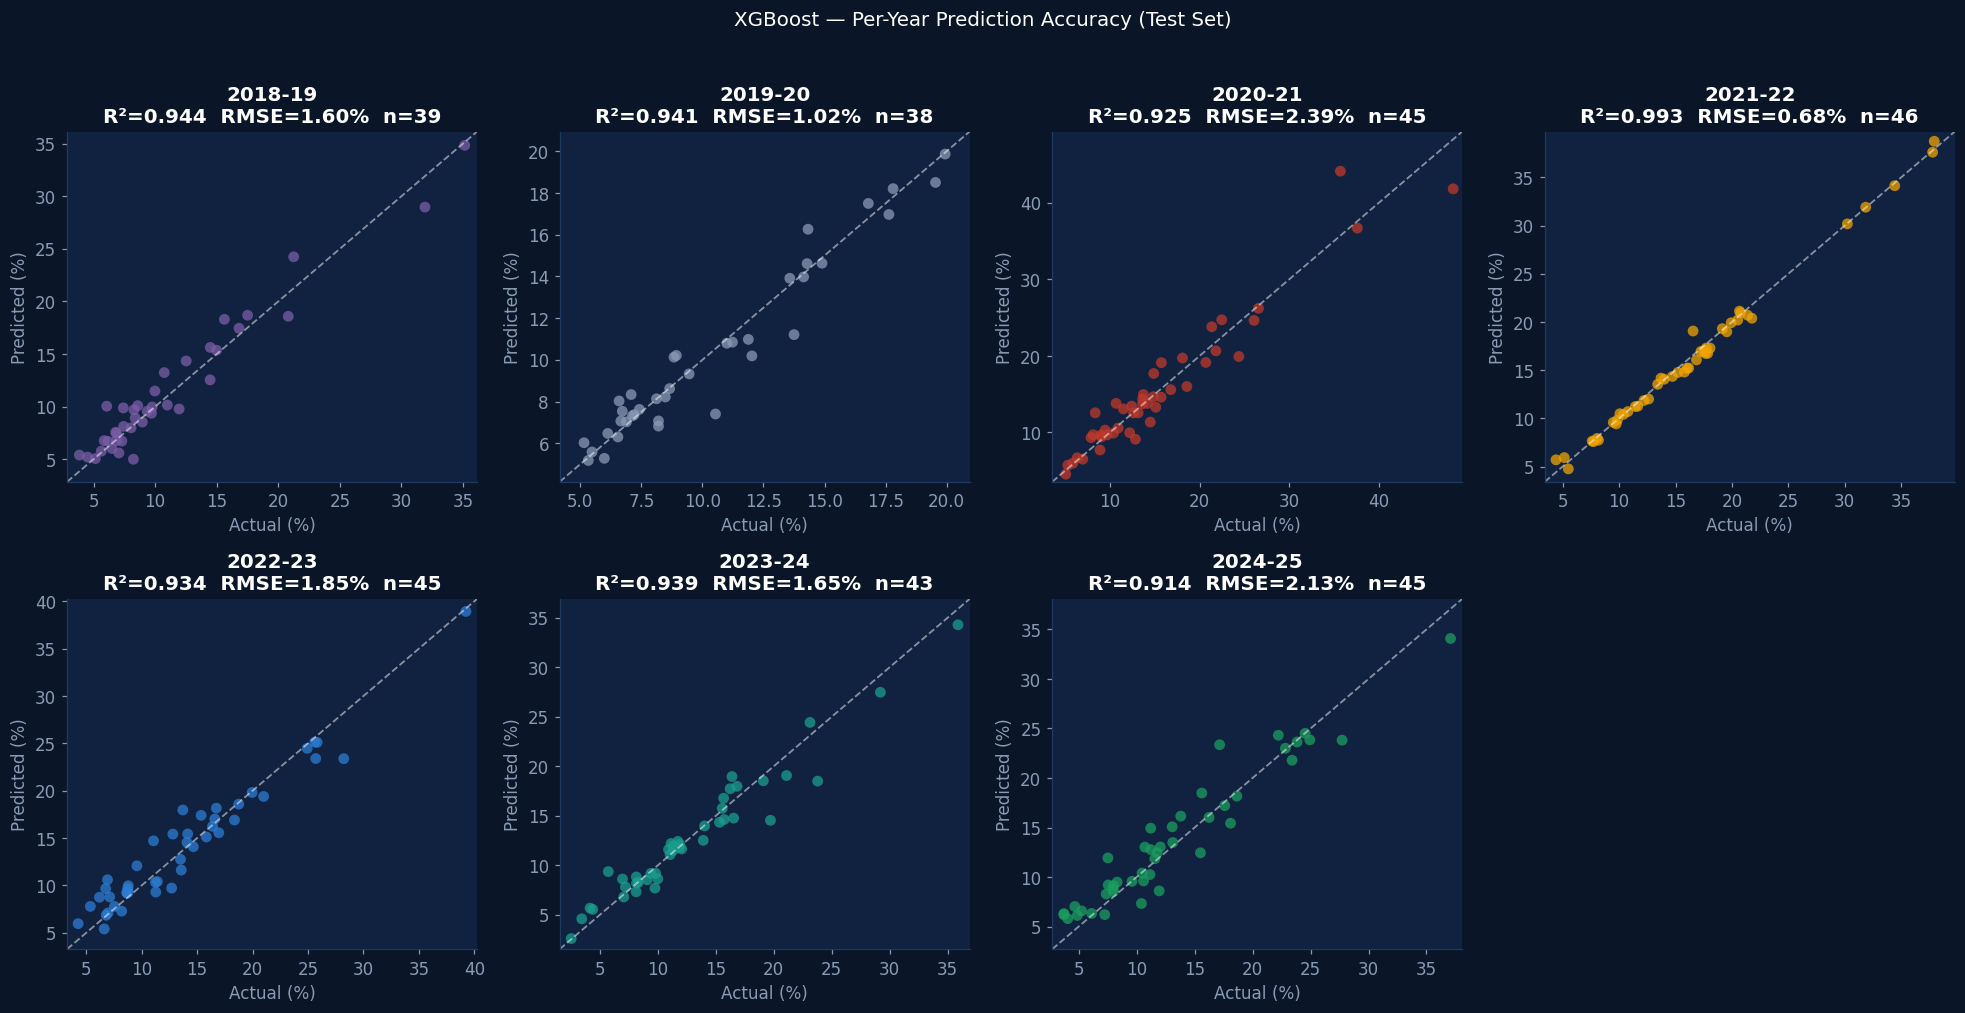

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes_flat = axes.flatten()

for i, yr in enumerate(ALL_YEARS):
    ax   = axes_flat[i]
    mask = yr_te == yr
    if mask.sum() == 0:
        ax.axis('off'); continue
    yt_yr = y_te[mask]; yp_yr = y_pred_xgb[mask]
    r2_yr   = r2_score(yt_yr, yp_yr)
    rmse_yr = np.sqrt(mean_squared_error(yt_yr, yp_yr)) * 100
    ax.scatter(yt_yr*100, yp_yr*100, color=YEAR_COLORS[yr],
               alpha=0.75, s=50, edgecolors='none')
    mn = min(yt_yr.min(), yp_yr.min())*100 - 1
    mx = max(yt_yr.max(), yp_yr.max())*100 + 1
    ax.plot([mn,mx],[mn,mx], color='white', lw=1.2, ls='--', alpha=0.5)
    ax.set_xlabel('Actual (%)'); ax.set_ylabel('Predicted (%)')
    ax.set_title(f'{yr}\nR²={r2_yr:.3f}  RMSE={rmse_yr:.2f}%  n={mask.sum()}')
    ax.set_xlim(mn,mx); ax.set_ylim(mn,mx)

axes_flat[-1].axis('off')
plt.suptitle('XGBoost — Per-Year Prediction Accuracy (Test Set)',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 18. Final Summary

In [20]:
print("=" * 58)
print("FINAL RESULTS — Decision Tree vs XGBoost")
print("=" * 58)
print(f"{'Model':<30} {'Test RMSE':>10} {'Test R²':>9}")
print("-" * 58)

for label, yp in [
    ('Decision Tree (default)',              dt_def.predict(X_te)),
    (f'Decision Tree (tuned d={dt_best.get_depth()})', y_pred_dt),
    ('XGBoost (default)',                    xgb_def.predict(X_te)),
    ('XGBoost (tuned)',                      y_pred_xgb),
]:
    rmse = np.sqrt(mean_squared_error(y_te, yp)) * 100
    r2   = r2_score(y_te, yp)
    star = '  <- best' if label == 'XGBoost (tuned)' else ''
    print(f"  {label:<30} {rmse:>8.3f}%  {r2:>8.4f}{star}")

print()
print(f"Dataset  : {len(ml)} district-year observations (7 years: 2018-19 to 2024-25)")
print(f"Districts: ~{ml['DIST_KEY'].nunique()} unique Nebraska school districts")
print(f"Features : {len(FEATURES)} (FRL%, absence rates, HS%, urban, size, year)")
print(f"Split    : 80/20 stratified by year, seed=42")
print(f"Tuning   : GridSearchCV 5-fold CV on training set only")

FINAL RESULTS — Decision Tree vs XGBoost
Model                           Test RMSE   Test R²
----------------------------------------------------------
  Decision Tree (default)           2.562%    0.8801
  Decision Tree (tuned d=8)         1.830%    0.9388
  XGBoost (default)                 1.870%    0.9361
  XGBoost (tuned)                   1.721%    0.9459  <- best

Dataset  : 1501 district-year observations (7 years: 2018-19 to 2024-25)
Districts: ~240 unique Nebraska school districts
Features : 9 (FRL%, absence rates, HS%, urban, size, year)
Split    : 80/20 stratified by year, seed=42
Tuning   : GridSearchCV 5-fold CV on training set only


---
**Next steps:** Write up contextual interpretations for each section and compile into a PDF report.
